In [1]:
from unittest import installHandler
%matplotlib inline

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


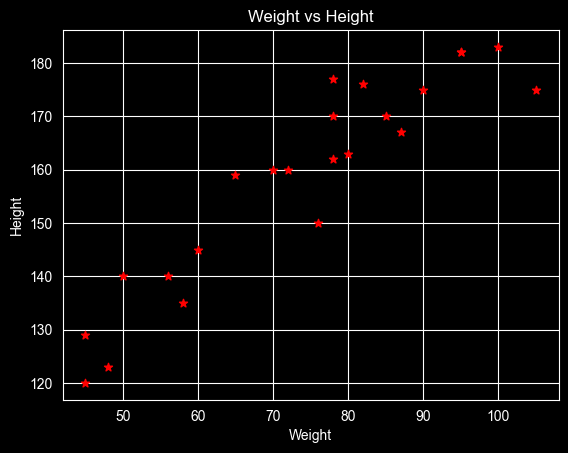

In [4]:
#Scatter Plot
plt.scatter(df['Weight'],df['Height'],color='red',marker="*")
plt.xlabel("Weight")
plt.ylabel("Height")
plt.title("Weight vs Height")
plt.show()

In [5]:
#Correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


In [6]:
#Seaborn for visualization
!pip install seaborn


[notice] A new release of pip available: 22.2.2 -> 26.1.1
[notice] To update, run: C:\Users\Sumit Dnyaneshwar\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [7]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [8]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


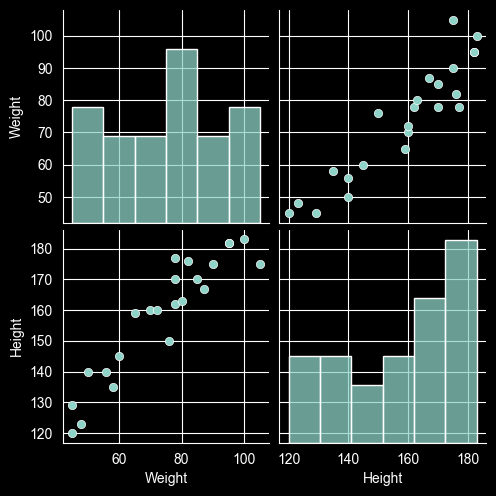

In [9]:
import seaborn as sns
sns.pairplot(df)

In [10]:
#Independent feature and dependent feature
X = df[["Weight"]] #ind. feature should be DataFrame or 2D array.
print(type(X))
print(X.head())

y = df["Height"]
print(type(y)) # This variable can be in series or 1D array.
y.head()

<class 'pandas.DataFrame'>
   Weight
0      45
1      58
2      48
3      60
4      70
<class 'pandas.Series'>


0    120
1    135
2    123
3    145
4    160
Name: Height, dtype: int64

In [11]:
import sys
!"{sys.executable}" -m pip install --upgrade pip

In [12]:
import sys
!"{sys.executable}" -m pip install scikit-learn

In [13]:
from sklearn.model_selection import train_test_split

In [18]:
x = df[["Weight"]]
y = df["Height"]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.25,random_state = 42)

In [19]:
x_train.shape

(17, 1)

In [20]:
#Standardization
from sklearn.preprocessing import StandardScaler

In [21]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)

In [22]:
x_test = scaler.transform(x_test)
x_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [24]:
#Apply simple Linear Regression
from sklearn.linear_model import LinearRegression

In [28]:
regression = LinearRegression(n_jobs = -1)

In [30]:
regression.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
print("Coefficient or slope : ",regression.coef_)
print("Intercept : ",regression.intercept_)

Coefficient or slope :  [17.2982057]
Intercept :  156.47058823529412


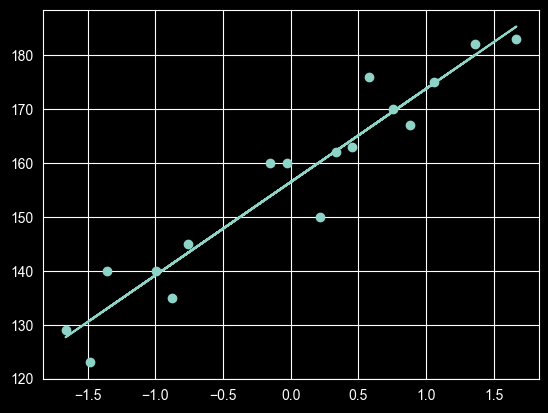

In [35]:
#Plot training data, plot best fit line.
plt.scatter(x_train,y_train)
plt.plot(x_train,regression.predict(x_train))

### Prediction of test data
1.Predicted height output = intercept + coef_(Weights)
2.y_pred_test = 156.470 + 17.29(x_test)

In [36]:
#Prediction for test data
y_pred = regression.predict(x_test)

In [37]:
#Performance metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [38]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

114.84069295228699
9.66512588679501
10.716374991212605


## R Square
Formula
R^2 = 1 - SSR/SST
 R^2 - Coefficient of determination
 SSR - Sum of Squares of Residuals
 SST - Total Sum of Squares

In [39]:
from sklearn.metrics import r2_score

In [40]:
score = r2_score(y_test,y_pred)
print(score)

0.7360826717981276


Adjusted R^2 = 1 -[(1-R^2)*(n-1)/(n-k-1)]

where:
R^2 - the R^2 of model  n - the number of observations  k - the number of predictor values


In [41]:
1-(1 - score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)

0.6701033397476595

In [44]:
#OLS Linear Regression
import statsmodels.api as sm

In [45]:
model = sm.OLS(y_train,x_train).fit()

In [47]:
prediction = model.predict(x_test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [48]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Sat, 09 May 2026   Prob (F-statistic):                       0.664
Time:                        10:35:07   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [50]:
# Prediction for new data
regression.predict(scaler.transform([[72]]))  # scaler.transform() is used for standardization.

C:\Users\Sumit Dnyaneshwar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])